In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
df = pd.read_csv('data_training.csv', parse_dates=['datetime'])

train_start, train_end = '2024-01-01', '2024-03-30'
test_start, test_end = '2024-04-01', '2024-06-30'

treino = df[(df['datetime'] >= train_start) & (df['datetime'] <= train_end)]
validacao = df[(df['datetime'] >= test_start) & (df['datetime'] <= test_end)]

for df in [treino, validacao]:
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day    
    df['hour'] = df['datetime'].dt.hour
    df['minute'] = df['datetime'].dt.minute
    df.drop(columns=['datetime','date','close','open','low','high','volume','average','amount_stock','id_ticker','business'], inplace=True)

X_train = treino.drop(columns=['trend'])  
y_train = treino['trend']  

X_valid = validacao.drop(columns=['trend'])  
y_valid = validacao['trend'] 

In [19]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

In [20]:
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Acurácia do modelo 0 (fold): 0.7595
Acurácia do modelo 1 (fold): 0.7559
Acurácia do modelo 2 (fold): 0.7441
Acurácia do modelo 3 (fold): 0.7559
Acurácia do modelo 4 (fold): 0.7604
Acurácia do modelo 5 (fold): 0.7734
Acurácia do modelo 6 (fold): 0.7699
Acurácia do modelo 7 (fold): 0.7367
Acurácia do modelo 8 (fold): 0.7521
Acurácia média do Cross-Validation: 0.7564 ± 0.0108
Acurácia do ensemble no conjunto de teste: 0.5798


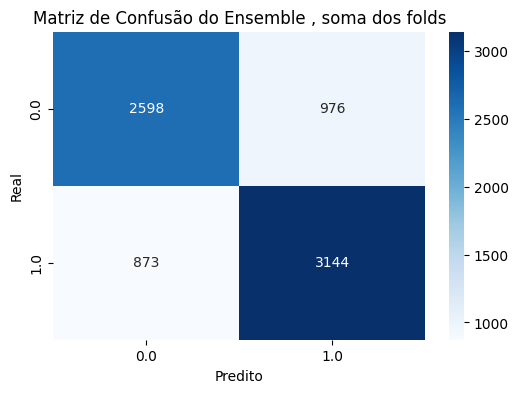

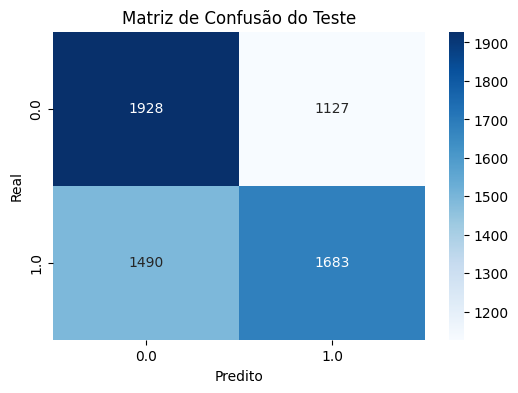

In [21]:
cv = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)

modelos_treinados = []
scores = []
y_valid_total = []
y_pred_total = []

for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):                
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    modelo_clone = clone(modelo)
    modelo_clone.fit(X_fold_train, y_fold_train)
    
    y_pred = modelo_clone.predict(X_fold_val)
    score = accuracy_score(y_fold_val, y_pred)
    
    modelos_treinados.append((f'modelo_{i}', modelo_clone))
    scores.append(score)

    print(f'Acurácia do modelo {i} (fold): {score:.4f}')

    y_valid_total.extend(y_fold_val)
    y_pred_total.extend(y_pred)

# Criar ensemble com os modelos treinados
ensemble = VotingClassifier(estimators=modelos_treinados, voting='hard') 

# Treina o ensemble no conjunto completo de treino
ensemble.fit(X_train, y_train)

y_pred_ensemble = ensemble.predict(X_valid)
final_accuracy = accuracy_score(y_valid, y_pred_ensemble)

cm = confusion_matrix(y_valid_total, y_pred_total)

print(f'Acurácia média do Cross-Validation: {np.mean(scores):.4f} ± {np.std(scores):.4f}')
print(f'Acurácia do ensemble no conjunto de teste: {final_accuracy:.4f}')

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["0.0", "1.0"], yticklabels=["0.0", "1.0"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão do Ensemble , soma dos folds")
plt.show()

matriz_confusao = confusion_matrix(y_valid, y_pred_ensemble)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_valid), yticklabels=np.unique(y_valid))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Teste')
plt.show()

Acurácia do modelo 0 (fold): 0.7595
Acurácia do modelo 1 (fold): 0.7559
Acurácia do modelo 2 (fold): 0.7441
Acurácia do modelo 3 (fold): 0.7559
Acurácia do modelo 4 (fold): 0.7604
Acurácia do modelo 5 (fold): 0.7734
Acurácia do modelo 6 (fold): 0.7699
Acurácia do modelo 7 (fold): 0.7367
Acurácia do modelo 8 (fold): 0.7521
Acurácia média do Cross-Validation: 0.7564 ± 0.0108
Acurácia do ensemble no conjunto de teste: 0.5798
Acurácia do ensemble nos dados de treinamento: 1.0000


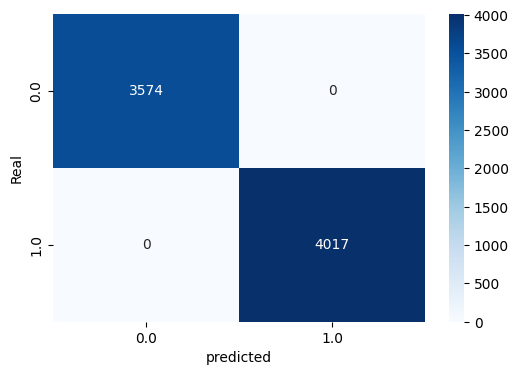

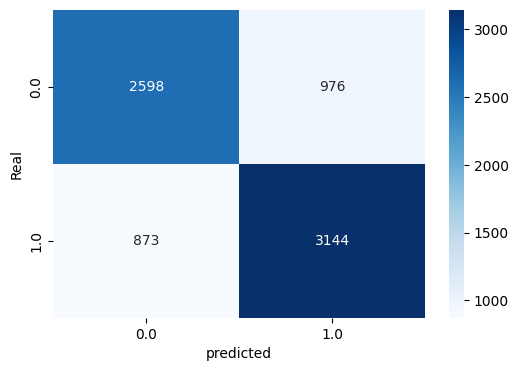

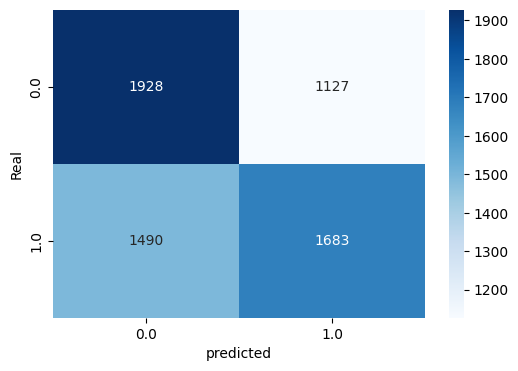

In [22]:

#faça uma matriz de confusao que pega o ensemble final com votaçao e passa nos dados que foi usado no cross validation com nome de dados de treinamento

# Definir validação cruzada estratificada
cv = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)

# Armazena os modelos treinados, os scores da validação e as previsões
modelos_treinados = []
scores = []
y_valid_total = []
y_pred_total = []
y_train_total = []  # Para armazenar os dados reais de treinamento
y_train_pred_total = []  # Para armazenar as previsões do ensemble nos dados de treinamento
y_valid_cv_total = []  # Para armazenar as previsões nos dados de validação cruzada

# Treinando os modelos e coletando previsões
for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):                
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    modelo_clone = clone(modelo)
    modelo_clone.fit(X_fold_train, y_fold_train)
    
    y_pred = modelo_clone.predict(X_fold_val)
    score = accuracy_score(y_fold_val, y_pred)
    
    modelos_treinados.append((f'modelo_{i}', modelo_clone))
    scores.append(score)

    # Exibe a acurácia individual do fold
    print(f'Acurácia do modelo {i} (fold): {score:.4f}')

    # Armazena os dados de validação e previsões para matriz de confusão
    y_valid_total.extend(y_fold_val)
    y_pred_total.extend(y_pred)

    # Armazena os dados de treinamento e previsões do ensemble para a matriz de confusão final
    y_train_total.extend(y_fold_train)
    y_train_pred_total.extend(modelo_clone.predict(X_fold_train))

    # Armazena os dados de validação cruzada
    y_valid_cv_total.extend(y_fold_val)

# Criar ensemble com os modelos treinados
ensemble = VotingClassifier(estimators=modelos_treinados, voting='hard') 

# Treina o ensemble no conjunto completo de treino
ensemble.fit(X_train, y_train)

# Avalia o ensemble nos dados de treinamento usados no cross-validation
y_pred_ensemble_train = ensemble.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_ensemble_train)

# Avalia o ensemble nos dados de teste
y_pred_ensemble_test = ensemble.predict(X_valid)
test_accuracy = accuracy_score(y_valid, y_pred_ensemble_test)

# Calcula matriz de confusão para os dados de treinamento
'''cm_train = confusion_matrix(y_train_total, y_train_pred_total)
'''
cm_train = confusion_matrix(y_train, y_pred_ensemble_train)

# Calcula matriz de confusão para os dados de validação cruzada (todos os folds)
cm_valid_cv = confusion_matrix(y_valid_cv_total, y_pred_total)

# Calcula matriz de confusão para os dados de teste
cm_test = confusion_matrix(y_valid, y_pred_ensemble_test)

# Exibe os resultados
print(f'Acurácia média do Cross-Validation: {np.mean(scores):.4f} ± {np.std(scores):.4f}')
print(f'Acurácia do ensemble no conjunto de teste: {test_accuracy:.4f}')
print(f'Acurácia do ensemble nos dados de treinamento: {train_accuracy:.4f}')

# Plot da matriz de confusão para os dados de treinamento (usados no cross-validation)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel("predicted")
plt.ylabel("Real")
plt.title("")
plt.show()

# Plot da matriz de confusão para os dados de validação cruzada (todos os folds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_valid_cv, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel("predicted")
plt.ylabel("Real")
plt.title("")
plt.show()

# Plot da matriz de confusão para os dados de teste (dados de validação)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=["0.0", "1.0"], yticklabels=["0.0", "1.0"])
plt.xlabel("predicted")
plt.ylabel("Real")
plt.title("")
plt.show()

In [23]:
print('Relatório de Classificação:')
print(classification_report(y_valid, y_pred_ensemble))

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.56      0.63      0.60      3055
         1.0       0.60      0.53      0.56      3173

    accuracy                           0.58      6228
   macro avg       0.58      0.58      0.58      6228
weighted avg       0.58      0.58      0.58      6228



In [24]:
importances = modelo.feature_importances_
feature_names = X_train.columns
sorted_indices = np.argsort(importances)[::-1]

for i in sorted_indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")


day: 0.1604
Bands_Norm: 0.1251
NSMA_3: 0.1102
NSMA_11: 0.1014
NSMA_5: 0.0999
NSMA_7: 0.0991
NSMA_9: 0.0973
hour: 0.0935
minute: 0.0723
month: 0.0408
year: 0.0000
